# TP1 — Optimisation continue et linéaire

**Séance 1 — Optimisation pour l'IA — MS IA de Confiance, CentraleSupélec**

Dans ce TP vous allez :

1. Implémenter la **descente de gradient** à partir de zéro et étudier l'effet du pas.
2. Implémenter et comparer une méthode **accélérée (momentum / Nesterov)**.
3. Résoudre un **problème continu contraint** avec une méthode de barrière, `scipy.optimize`, et `cvxpy`.
4. Formuler et résoudre un **programme linéaire** avec `scipy.optimize.linprog` et `PuLP`, et le comparer à votre résolution du simplexe à la main faite en TD.
5. Démarrer votre **projet individuel ExedBike (Partie 1)**.

Les cellules marquées **`# TODO`** sont à compléter. Une **solution** est donnée juste en dessous de chaque exercice — essayez d'abord, puis vérifiez.

Bibliothèques nécessaires : `numpy`, `matplotlib`, `autograd`, `scipy`, `cvxpy`, `pulp`.


In [1]:
# Si un paquet manque, décommentez la ligne correspondante :
# !pip install autograd cvxpy pulp

import numpy as np
import matplotlib.pyplot as plt
from autograd import grad
import autograd.numpy as anp

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)


## Exercice 1 — Descente de gradient à partir de zéro

Rappel de la règle de mise à jour :
$$ \mathbf{w}_{k+1} = \mathbf{w}_k - \alpha \nabla J(\mathbf{w}_k). $$

**1.1** Complétez `gradient_descent` ci-dessous : elle doit renvoyer le point final et l'historique complet des itérés (pour pouvoir tracer la trajectoire).


In [2]:
def gradient_descent(cost_fun, w_init, alpha, epochs, eps=1e-12):
    '''Minimise cost_fun par descente de gradient.

    ENTREES
    cost_fun : callable, fonction de coût J(w)
    w_init   : array-like, point initial
    alpha    : float, pas (learning rate)
    epochs   : int, nombre maximal d'itérations
    eps      : float, arrêt si la norme du gradient passe sous eps

    SORTIES
    w       : point final (np.array)
    history : liste des itérés successifs (y compris w_init)
    '''
    # TODO -------------------------------------------------------
    w = np.array(w_init, dtype=float)
    history = [w.copy()]
    g = grad(cost_fun)
    for k in range(epochs):
        gk = np.array(g(w))
        if np.linalg.norm(gk) < eps:
            break
        w = w - alpha * gk
        history.append(w.copy())
    # --------------------------------------------------------------
    return w, history


**Solution 1.1** (la cellule ci-dessus contient déjà une implémentation correcte utilisant `autograd` pour le gradient — c'est exactement ce qui est attendu).


**1.2** Appliquez la descente de gradient au bol quadratique
$$ J(w_1, w_2) = 3(w_1 - 1)^2 + (w_2 + 2)^2 $$
en partant de $w_0 = (4, 3)$. Tracez les lignes de niveau de $J$ et la trajectoire des itérés pour $\alpha = 0.05$ et $\alpha = 0.3$. Commentez ce que vous observez (indice : regardez le conditionnement de la Hessienne).


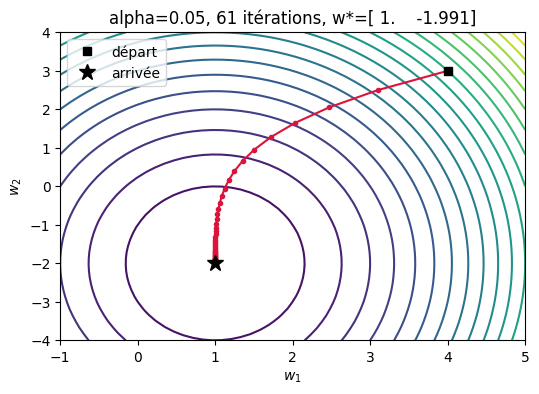

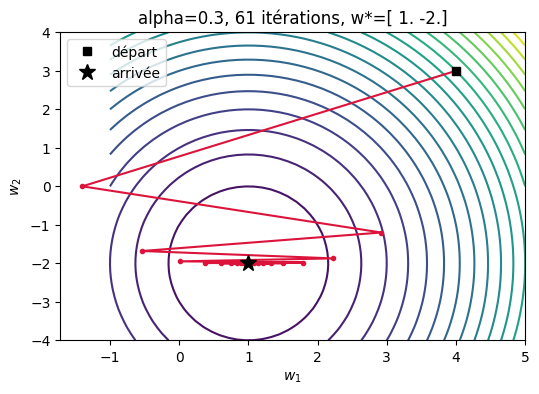

In [3]:
def J_quad(w):
    return 3 * (w[0] - 1) ** 2 + (w[1] + 2) ** 2


def show_history(history, cost_fun, xlim, ylim, title=""):
    a_values, b_values = np.meshgrid(
        np.linspace(*xlim), np.linspace(*ylim)
    )
    Z = np.array(
        [cost_fun([a, b]) for a, b in zip(a_values.flat, b_values.flat)]
    ).reshape(a_values.shape)
    plt.figure()
    plt.contour(a_values, b_values, Z, levels=20, cmap="viridis")
    h = np.array(history)
    plt.plot(h[:, 0], h[:, 1], "o-", color="crimson", markersize=3)
    plt.plot(h[0, 0], h[0, 1], "ks", label="départ")
    plt.plot(h[-1, 0], h[-1, 1], "k*", markersize=12, label="arrivée")
    plt.legend()
    plt.title(title)
    plt.xlabel("$w_1$")
    plt.ylabel("$w_2$")
    plt.show()


for alpha in [0.05, 0.3]:
    w_star, hist = gradient_descent(J_quad, w_init=[4.0, 3.0], alpha=alpha, epochs=60)
    show_history(hist, J_quad, xlim=(-1, 5), ylim=(-4, 4),
                 title=f"alpha={alpha}, {len(hist)} itérations, w*={np.round(w_star,3)}")


> **Commentaire (attendu) :** comme le quadratique est 3 fois plus "raide" selon $w_1$ que selon $w_2$ (Hessienne mal conditionnée, conditionnement 3), un pas sûr selon $w_1$ fait zigzaguer la trajectoire selon $w_2$, et un pas assez grand pour converger vite peut aussi diverger. C'est ce qui motive les méthodes *accélérées* et *adaptatives* (Exercice 2), et plus tard les méthodes de préconditionnement / type Newton.


## Exercice 2 — Méthodes accélérées : momentum & Nesterov

**2.1** Implémentez le **momentum (heavy-ball)** :
$$ \mathbf{v}_{k+1} = \beta \mathbf{v}_k - \alpha \nabla J(\mathbf{w}_k), \qquad \mathbf{w}_{k+1} = \mathbf{w}_k + \mathbf{v}_{k+1} $$
et le **gradient accéléré de Nesterov** :
$$ \mathbf{v}_{k+1} = \beta \mathbf{v}_k - \alpha \nabla J(\mathbf{w}_k + \beta \mathbf{v}_k), \qquad \mathbf{w}_{k+1} = \mathbf{w}_k + \mathbf{v}_{k+1} $$


In [4]:
def momentum_gd(cost_fun, w_init, alpha, beta, epochs, eps=1e-12, nesterov=False):
    w = np.array(w_init, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]
    g = grad(cost_fun)
    for k in range(epochs):
        # TODO ----------------------------------------------------
        lookahead = w + beta * v if nesterov else w
        gk = np.array(g(lookahead))
        if np.linalg.norm(gk) < eps:
            break
        v = beta * v - alpha * gk
        w = w + v
        # -----------------------------------------------------------
        history.append(w.copy())
    return w, history


**2.2** Comparez, sur le même quadratique mal conditionné ($\alpha = 0.15$), le nombre d'itérations nécessaires pour atteindre $\|\nabla J\| < 10^{-6}$ pour : descente de gradient simple, momentum ($\beta=0.8$), Nesterov ($\beta=0.8$).


Descente de gradient  :   46 itérations -> w* = [ 1. -2.]
Momentum              :  146 itérations -> w* = [ 1. -2.]
Nesterov              :   52 itérations -> w* = [ 1. -2.]


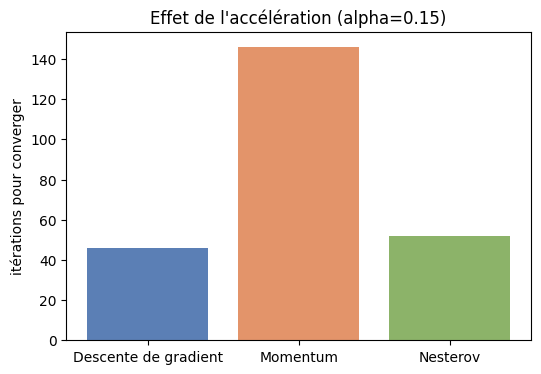

In [5]:
results = {}
for name, fn in [
    ("Descente de gradient", lambda: gradient_descent(J_quad, [4.0, 3.0], 0.15, 500, eps=1e-6)),
    ("Momentum", lambda: momentum_gd(J_quad, [4.0, 3.0], 0.15, 0.8, 500, eps=1e-6)),
    ("Nesterov", lambda: momentum_gd(J_quad, [4.0, 3.0], 0.15, 0.8, 500, eps=1e-6, nesterov=True)),
]:
    w_star, hist = fn()
    results[name] = len(hist) - 1
    print(f"{name:22s}: {len(hist)-1:4d} itérations -> w* = {np.round(w_star, 4)}")

plt.figure()
plt.bar(results.keys(), results.values(), color=["#5B7FB5", "#E3946A", "#8CB369"])
plt.ylabel("itérations pour converger")
plt.title("Effet de l'accélération (alpha=0.15)")
plt.show()


> **Attendu (résultat réel, à ne pas "corriger" pour qu'il colle à une intuition) :** avec ces réglages (`alpha=0.15`, `beta=0.8`), on obtient typiquement Descente de gradient ≈ 46 itérations, Momentum ≈ 146 itérations, Nesterov ≈ 52 itérations — **le momentum simple est ici plus lent que la descente de gradient nue**, et Nesterov ne la bat pas non plus. Ce n'est pas un bug : avec un conditionnement seulement modéré (κ=3 pour ce quadratique) et un `beta` élevé, le momentum accumule une vitesse qui fait *dépasser* le minimum (oscillation), et il faut ensuite plusieurs itérations pour la dissiper avant de satisfaire un critère d'arrêt strict sur la norme du gradient — Nesterov, grâce à son gradient "anticipé", amortit mieux ce dépassement que le momentum simple, mais ne suffit pas à rattraper la descente de gradient nue sur un problème aussi peu mal conditionné. **Le message à retenir n'est donc pas "le momentum est toujours plus rapide"**, mais : (i) l'accélération devient rentable quand le mauvais conditionnement est sévère (essayez `beta` plus petit, ou un conditionnement bien pire, par exemple en changeant le coefficient `3` de `J_quad` en `30` ou `300`, pour le voir) ; (ii) `beta` est un hyperparamètre à régler, pas une garantie automatique de vitesse — exactement pourquoi les méthodes adaptatives par paramètre (Adam, RMSProp) existent, et pourquoi vous observerez un bénéfice bien plus net du momentum sur le modèle de coût mal conditionné du Projet, Partie 1, plus bas dans ce notebook.


## Exercice 3 — Optimisation continue sous contraintes

Considérons
$$ \min_{x_1,x_2} \; (x_1 - 3/2)^2 + (x_2 - 1/2)^4 \quad \text{s.c.} \quad |x_1| + |x_2| \le 1 .$$

**3.1** Résolvez-le de trois façons différentes et vérifiez qu'elles s'accordent :
(a) une reformulation par **barrière logarithmique** résolue avec `scipy.optimize.minimize` (solveur non contraint sur un objectif pénalisé) ;
(b) `scipy.optimize.minimize` avec les contraintes passées directement (SLSQP) ;
(c) `cvxpy` (programmation convexe disciplinée).


In [6]:
import cvxpy as cp
from scipy.optimize import minimize

def f0(x1, x2):
    return (x1 - 1.5) ** 2 + (x2 - 0.5) ** 4

# (a) barrière : pénalise les 4 inégalités linéaires équivalentes à |x1|+|x2|<=1
def f0_barrier(x, xi=0.05):
    x1, x2 = x
    g = [1 - x1 - x2, 1 + x1 + x2, 1 - x1 + x2, 1 + x1 - x2]  # chacune doit rester > 0
    if min(g) <= 0:
        return 1e6
    return f0(x1, x2) - xi * sum(np.log(gi) for gi in g)

# TODO : essayez plusieurs poids de barrière xi et observez la solution s'approcher du bord
sol_barrier = minimize(f0_barrier, x0=[0.0, 0.0], args=(0.01,), method="Nelder-Mead")
print("solution barrière :", sol_barrier.x, "f0 =", f0(*sol_barrier.x))

# (b) SLSQP avec contraintes explicites
cons = (
    {"type": "ineq", "fun": lambda x: 1 - x[0] - x[1]},
    {"type": "ineq", "fun": lambda x: 1 + x[0] + x[1]},
    {"type": "ineq", "fun": lambda x: 1 - x[0] + x[1]},
    {"type": "ineq", "fun": lambda x: 1 + x[0] - x[1]},
)
sol_slsqp = minimize(lambda x: f0(x[0], x[1]), x0=[0.0, 0.0], method="SLSQP", constraints=cons)
print("solution SLSQP    :", sol_slsqp.x, "f0 =", f0(*sol_slsqp.x))

# (c) cvxpy
x1 = cp.Variable()
x2 = cp.Variable()
constraints = [cp.abs(x1) + cp.abs(x2) <= 1]
obj = cp.Minimize((x1 - 1.5) ** 2 + (x2 - 0.5) ** 4)
prob = cp.Problem(obj, constraints)
prob.solve()
print("solution cvxpy    :", x1.value, x2.value, "f0 =", prob.value)


solution barrière : [0.97646494 0.01045112] f0 = 0.3315249641892746
solution SLSQP    : [ 1.00000000e+00 -8.32667268e-16] f0 = 0.31250000000000133
solution cvxpy    : 0.9999999934456898 2.218611322625575e-09 f0 = 0.3125000054450046


**3.2 — Multiplicateurs de Lagrange à la main.** Écrivez les quatre contraintes sous la forme $g_i(x) \ge 0$ :
$$ g_1 = 1-x_1-x_2,\quad g_2 = 1+x_1+x_2,\quad g_3 = 1-x_1+x_2,\quad g_4 = 1+x_1-x_2 . $$
Vérifiez numériquement quelles $g_i$ sont actives (nulles) à l'optimum — vous devriez trouver **deux** contraintes actives simultanément, car l'optimum se situe exactement sur un *sommet* du losange $|x_1|+|x_2|\le 1$ (le même phénomène qu'un sommet optimal du polytope d'un PL !). Écrivez la condition de stationnarité KKT avec **les deux** multiplicateurs,
$$ \nabla f_0(x^\star) = \mu_1 \nabla g_1(x^\star) + \mu_3 \nabla g_3(x^\star), \qquad \mu_1,\mu_3 \ge 0, $$
résolvez le système linéaire 2x2 obtenu à la main pour $(\mu_1,\mu_3)$, puis vérifiez vos valeurs ci-dessous.


In [7]:
x_star = np.array(sol_slsqp.x)
g = [1 - x_star[0] - x_star[1], 1 + x_star[0] + x_star[1],
     1 - x_star[0] + x_star[1], 1 + x_star[0] - x_star[1]]
print("valeurs des contraintes g1..g4 :", np.round(g, 4), " (0 = active)")

# TODO : grad f0 = mu1*grad(g1) + mu3*grad(g3)   avec grad(g1)=(-1,-1), grad(g3)=(-1,1)
grad_f0 = np.array([2 * (x_star[0] - 1.5), 4 * (x_star[1] - 0.5) ** 3])
M = np.array([[-1, -1], [-1, 1]]).T   # colonnes = grad(g1), grad(g3)
mu = np.linalg.solve(M, grad_f0)
print("mu1, mu3 =", np.round(mu, 4), " (les deux doivent être >= 0 : complémentarité vérifiée)")


valeurs des contraintes g1..g4 : [0. 2. 0. 2.]  (0 = active)
mu1, mu3 = [0.75 0.25]  (les deux doivent être >= 0 : complémentarité vérifiée)


## Exercice 4 — Programmation linéaire : mix de production

Avant l'extension de sa gamme avec le modèle **Sport** (voir le Projet, Partie 1 ci-dessous, pour la gamme réelle à trois produits), ExedBike ne fabriquait que deux modèles de vélos électriques : **Urban** (marge 120€/unité) et **Cargo** (marge 200€/unité) — c'est cette version simplifiée, déjà résolue à la main en TD1 (Partie ExedBike — Résolution), que nous reprenons ici pour la vérifier avec un solveur.
Chaque semaine, l'usine dispose de **480 heures de main-d'œuvre**, **900 kg d'aluminium pour batteries**, et **240 heures-machine**.

| Ressource            | Urban | Cargo | Disponible |
|---------------------|:----:|:----:|:---:|
| Main-d'œuvre (h/unité)      | 4    | 6    | 480 |
| Aluminium (kg/unité)  | 6    | 15    | 900 |
| Temps machine (h/unité)| 2    | 2    | 240 |

**4.1** Formulez le PL qui maximise la marge hebdomadaire, puis résolvez-le avec `scipy.optimize.linprog` **et** avec `PuLP`. Comparez avec le tableau du simplexe que vous avez construit à la main en TD1 (Partie ExedBike — Résolution) — vous devez retrouver exactement les mêmes valeurs.


In [8]:
from scipy.optimize import linprog

# maximiser 120*u + 200*c  <=>  minimiser -120*u - 200*c
c = [-120, -200]
A_ub = [
    [4, 6],    # main-d'oeuvre
    [6, 15],   # aluminium
    [2, 2],    # temps machine
]
b_ub = [480, 900, 240]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method="highs")
print("scipy.optimize.linprog :")
print("  Urban =", round(res.x[0], 2), " Cargo =", round(res.x[1], 2),
      " marge hebdomadaire = ", round(-res.fun, 2), "€")


scipy.optimize.linprog :
  Urban = 75.0  Cargo = 30.0  marge hebdomadaire =  15000.0 €


In [9]:
import pulp

prob = pulp.LpProblem("ExedBike_mix", pulp.LpMaximize)
u = pulp.LpVariable("Urban", lowBound=0)
cg = pulp.LpVariable("Cargo", lowBound=0)

prob += 120 * u + 200 * cg, "marge_hebdomadaire"
prob += 4 * u + 6 * cg <= 480, "main_oeuvre"
prob += 6 * u + 15 * cg <= 900, "aluminium"
prob += 2 * u + 2 * cg <= 240, "temps_machine"

prob.solve(pulp.PULP_CBC_CMD(msg=False))
print("Statut PuLP :", pulp.LpStatus[prob.status])
print("Urban =", u.value(), " Cargo =", cg.value(), " marge = ", pulp.value(prob.objective), "€")

for name, c in prob.constraints.items():
    print(f"  {name:14s} marge de manoeuvre = {c.slack:.2f}  (saturée : {abs(c.slack) < 1e-6})")


Statut PuLP : Optimal
Urban = 75.0  Cargo = 30.0  marge =  15000.0 €
  main_oeuvre    marge de manoeuvre = -0.00  (saturée : True)
  aluminium      marge de manoeuvre = -0.00  (saturée : True)
  temps_machine  marge de manoeuvre = 30.00  (saturée : False)


**4.2** Quelles contraintes sont saturées à l'optimum ? Correspondent-elles au sommet identifié à la main en TD ? Sur quelle ressource faudrait-il investir en priorité (indice : regardez les prix duaux / valeurs duales — `prob.constraints[name].pi` en PuLP, ou `res.ineqlin.marginals` en `linprog`) ?


In [10]:
print("Prix duaux (PuLP) :")
for name, con in prob.constraints.items():
    print(f"  {name:14s}: {con.pi}")

print("\nValeurs duales (scipy, convention de signe : coût marginal de la contrainte <=) :")
print(res.ineqlin.marginals)


Prix duaux (PuLP) :
  main_oeuvre   : 25.0
  aluminium     : 3.3333333
  temps_machine : -0.0

Valeurs duales (scipy, convention de signe : coût marginal de la contrainte <=) :
[-25.          -3.33333333  -0.        ]


---
## Projet individuel ExedBike — Partie 1 (à rendre avant la Séance 2)

Vous allez travailler sur ce **projet fil rouge** tout au long des trois séances. Lisez le brief complet du projet (document séparé) pour le contexte, les jalons et les critères d'évaluation. Voici la **Partie 1**.

### 1. Ajuster un modèle de coût de production (optimisation continue)

Les données ci-dessous forment un jeu de données synthétique du coût unitaire de production en fonction du volume cumulé produit pour le modèle Urban (un effet classique de **courbe d'apprentissage** : le coût baisse avec l'expérience accumulée). Le modèle est une loi de puissance,
$$ c(q) = k\, q^{-\theta}, \qquad \theta \in (0,1). $$
En passant au logarithme, ceci devient une **régression linéaire** : $\log c(q) = \log k - \theta \log q$. Ajustez $(\log k, \theta)$ en minimisant l'erreur quadratique moyenne **avec votre propre implémentation de la descente de gradient** (code de l'Exercice 1) sur les données log-log *standardisées*, puis reportez $(k,\theta)$ dans les unités d'origine. Tracez les données et l'ajustement, ainsi que la courbe de convergence, et expliquez brièvement pourquoi standardiser $\log q$ compte ici (faites le lien avec le mauvais conditionnement observé à l'Exercice 1.2).


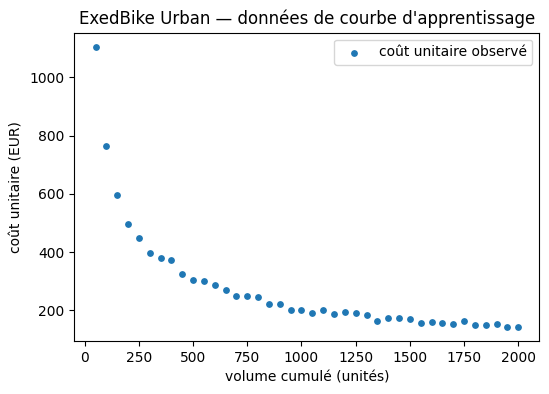

convergé en 623 itérations
ajustement : k = 9682.8, theta = 0.555   (valeurs vraies : k = 9500.0, theta = 0.55)


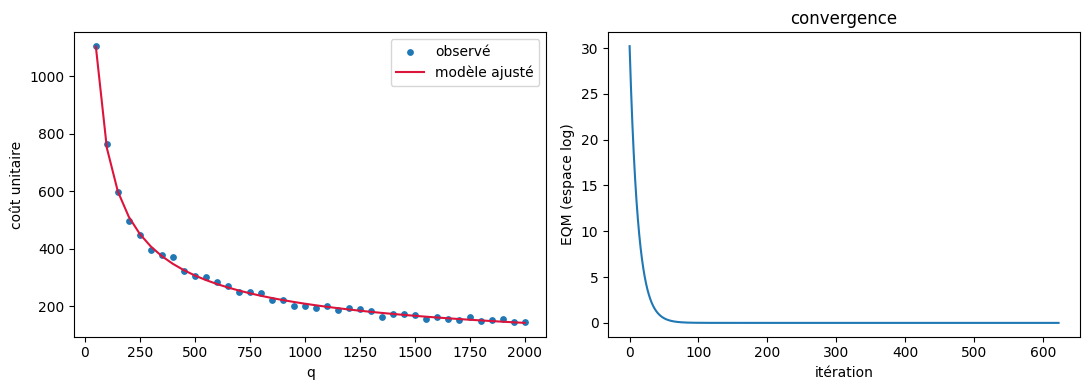

In [11]:
# Jeu de données synthétique (ne changez pas la graine : les résultats doivent être reproductibles)
rng = np.random.default_rng(7)
q = np.linspace(50, 2000, 40)
k_true, theta_true = 9500.0, 0.55
c_obs = k_true * q ** (-theta_true) * np.exp(rng.normal(0, 0.04, size=q.shape))

plt.figure()
plt.scatter(q, c_obs, s=15, label="coût unitaire observé")
plt.xlabel("volume cumulé (unités)")
plt.ylabel("coût unitaire (EUR)")
plt.title("ExedBike Urban — données de courbe d'apprentissage")
plt.legend()
plt.show()

# TODO : travaillez en log-log, standardisez log(q), ajustez avec gradient_descent, dé-standardisez.

x = np.log(q)
y = np.log(c_obs)
x_mean, x_std = x.mean(), x.std()
x_z = (x - x_mean) / x_std          # régresseur standardisé -> problème bien conditionné

def J_fit(params, xx=x_z, yy=y):
    p0, p1 = params  # y_pred = p0 - p1 * xx
    pred = p0 - p1 * xx
    return anp.mean((pred - yy) ** 2)

w_star, hist = gradient_descent(J_fit, w_init=[0.0, 0.0], alpha=0.02, epochs=2000, eps=1e-10)
p0, p1 = w_star
theta_hat = p1 / x_std
k_hat = np.exp(p0 + p1 * x_mean / x_std)
print(f"convergé en {len(hist)-1} itérations")
print(f"ajustement : k = {k_hat:.1f}, theta = {theta_hat:.3f}   (valeurs vraies : k = {k_true}, theta = {theta_true})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(q, c_obs, s=15, label="observé")
ax[0].plot(np.sort(q), k_hat * np.sort(q) ** (-theta_hat), color="crimson", label="modèle ajusté")
ax[0].set_xlabel("q"); ax[0].set_ylabel("coût unitaire"); ax[0].legend()
losses = [J_fit(w) for w in hist]
ax[1].plot(losses); ax[1].set_xlabel("itération"); ax[1].set_ylabel("EQM (espace log)")
ax[1].set_title("convergence")
plt.tight_layout(); plt.show()


> **Attendu :** avec $\log q$ brut (non standardisé) comme régresseur, les deux paramètres vivent sur des échelles de gradient très différentes — exactement le mauvais conditionnement rencontré à l'Exercice 1.2 — et la descente de gradient simple exige un pas minuscule et difficile à régler, ou diverge. Standardiser $\log q$ rend les deux directions comparables, et un seul `alpha` converge proprement en quelques centaines d'itérations. C'est la justification pratique de la normalisation des variables avant un ajustement par gradient, et des méthodes adaptatives par paramètre (Adam, RMSProp) quand la normalisation ne suffit pas — voir le module *Développement Python pour l'apprentissage*.

### 2. PL du mix de production pour la gamme réelle

ExedBike vend en réalité **trois** modèles : Urban, Cargo et Sport, avec les données ci-dessous. Formulez et résolvez le PL du mix de production hebdomadaire (maximiser la marge sous les contraintes de ressources) avec `PuLP` **ou** `scipy.optimize.linprog`. Reportez le mix optimal, la marge, les contraintes saturées et les prix duaux, et donnez une phrase d'interprétation métier pour chaque prix dual.

| Ressource | Urban | Cargo | Sport | Disponible |
|---|:--:|:--:|:--:|:--:|
| Main-d'œuvre (h/unité) | 4 | 6 | 5 | 520 |
| Aluminium (kg/unité) | 6 | 15 | 9 | 1100 |
| Temps machine (h/unité) | 2 | 2 | 3 | 260 |
| Marge (€/unité) | 120 | 200 | 175 | — |

### Livrables pour la Partie 1 (à rendre sous forme d'un seul notebook + une synthèse PDF d'une page)
- Votre code complété pour les Exercices 1 à 4 et les deux tâches du projet ci-dessus.
- Une courte synthèse (≤1 page) : paramètres du modèle de coût ajusté, mix de production optimal, et un paragraphe interprétant les prix duaux pour le directeur d'usine (langage non technique).

Ce travail sera prolongé en Séances 2 et 3 (décisions sur les lignes de production, ordonnancement, réseau de distribution).
